In [ ]:
## Setup

In [ ]:
!pip install easyocr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 15.5 MB/s eta 0:00:00


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='capture.jpg', quality=0.9):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';

            const constraints = {
                video: {
                    width: { ideal: 1920 },
                    height: { ideal: 1080 },
                    facingMode: 'environment'
                }
            };
            const stream = await navigator.mediaDevices.getUserMedia(constraints);

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

In [ ]:
## preprocessing

In [ ]:
import cv2
import numpy as np

def to_grayscale(image):
    if len(image.shape) == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image

def upscale(image, factor=2):
    return cv2.resize(image, None, fx=factor, fy=factor, interpolation=cv2.INTER_CUBIC)

def enhance_contrast(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image)

def preprocess_image(image):
    gray = to_grayscale(image)
    h, w = gray.shape
    if max(h, w) < 1000:
        gray = upscale(gray)
    contrast = enhance_contrast(gray)
    return contrast

In [ ]:
## OCR Engine

In [ ]:
import easyocr

reader = easyocr.Reader(['ar', 'en'], gpu=False)

def extract_medicine_details(image):
    results = reader.readtext(image)

    lines = []
    for bbox, text, conf in results:
        text = text.strip()
        if not text:
            continue
        top_left, top_right, bottom_right, bottom_left = bbox
        height = bottom_right[1] - top_right[1]
        lines.append({"text": text, "height": height, "confidence": conf})

    lines.sort(key=lambda x: x["height"], reverse=True)

    return {
        "name": lines[0]["text"] if len(lines) > 0 else "",
        "name_confidence": lines[0]["confidence"] if len(lines) > 0 else 0.0,
        "subtitle": lines[1]["text"] if len(lines) > 1 else "",
        "subtitle_confidence": lines[1]["confidence"] if len(lines) > 1 else 0.0,
        "avg_confidence": sum(l["confidence"] for l in lines) / len(lines) if lines else 0.0,
        "all_detected": [l["text"] for l in lines],
    }

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [ ]:
## Knowledge Base & Matching

In [ ]:
from google.colab import files
import json

uploaded_json = files.upload()
json_filename = list(uploaded_json.keys())[0]

with open(json_filename, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

knowledge_base = raw_data["records"]  # the actual medicine entries live here

print(f"Loaded {len(knowledge_base)} medicines")
print("\nFirst record:")
print(knowledge_base[0])

Saving sfda_packaging_data.json to sfda_packaging_data.json
Loaded 14 medicines

First record:
{'id': 'PKG-001', 'tradeName': {'en': 'Fusibact Cream 2% W-W'}, 'genericName': {'en': 'Fusidic Acid'}, 'dosageForm': {'en': 'Cream'}, 'strength': '2%', 'packSize': '15 (Tube)', 'manufacturer': {'name': 'Jamjoom Pharmaceuticals Factory Company', 'country': 'Saudi Arabia'}, 'registrationNumber': '0707245488', 'routeOfAdministration': 'Topical', 'registrationYear': 2001, 'legalStatus': 'Rx', 'drugType': 'Generic', 'atcCode': 'D06AX01', 'marketingAuthorizationHolder': 'Jamjoom Pharmaceuticals Factory Company', 'storageConditions': 'Store below 30°C', 'shelfLifeMonths': 36}


In [ ]:
from difflib import SequenceMatcher

def get_trade_name(entry):
    return entry.get("tradeName", {}).get("en", "")

def find_best_match(all_detected_lines, knowledge_base, min_score=0.5):
    """
    Tries EVERY detected OCR line against every knowledge base entry,
    not just the tallest line - the tallest text on a box isn't
    guaranteed to be the English trade name (could be Arabic script,
    a logo, a marketing tagline).

    This checks all candidates and keeps
    whichever line/entry pair scores highest overall.
    """
    best_entry = None
    best_score = 0.0
    best_line = ""

    for line in all_detected_lines:
        line_clean = line.strip().lower()
        if not line_clean:
            continue
        for entry in knowledge_base:
            trade_name = get_trade_name(entry).strip().lower()
            if not trade_name:
                continue
            score = SequenceMatcher(None, line_clean, trade_name).ratio()
            if score > best_score:
                best_score = score
                best_entry = entry
                best_line = line

    if best_score >= min_score:
        return best_entry, best_score, best_line
    return None, best_score, best_line

def format_medicine_info(entry):
    trade_name = get_trade_name(entry) or "Unknown"
    generic = entry.get("genericName", {}).get("en", "Unknown")
    form = entry.get("dosageForm", {}).get("en", "Unknown")
    strength = entry.get("strength", "Unknown")
    pack_size = entry.get("packSize", "Unknown")
    manufacturer = entry.get("manufacturer", {}).get("name", "Unknown")
    legal_status = entry.get("legalStatus", "Unknown")
    route = entry.get("routeOfAdministration", "Unknown")

    return (
        f"{trade_name}\n"
        f"Generic name: {generic}\n"
        f"Form: {form}, Strength: {strength}, Pack size: {pack_size}\n"
        f"Route: {route}\n"
        f"Manufacturer: {manufacturer}\n"
        f"Legal status: {legal_status}"
    )

In [ ]:
## Live Demo

<IPython.core.display.Javascript object>

Preprocessed image:


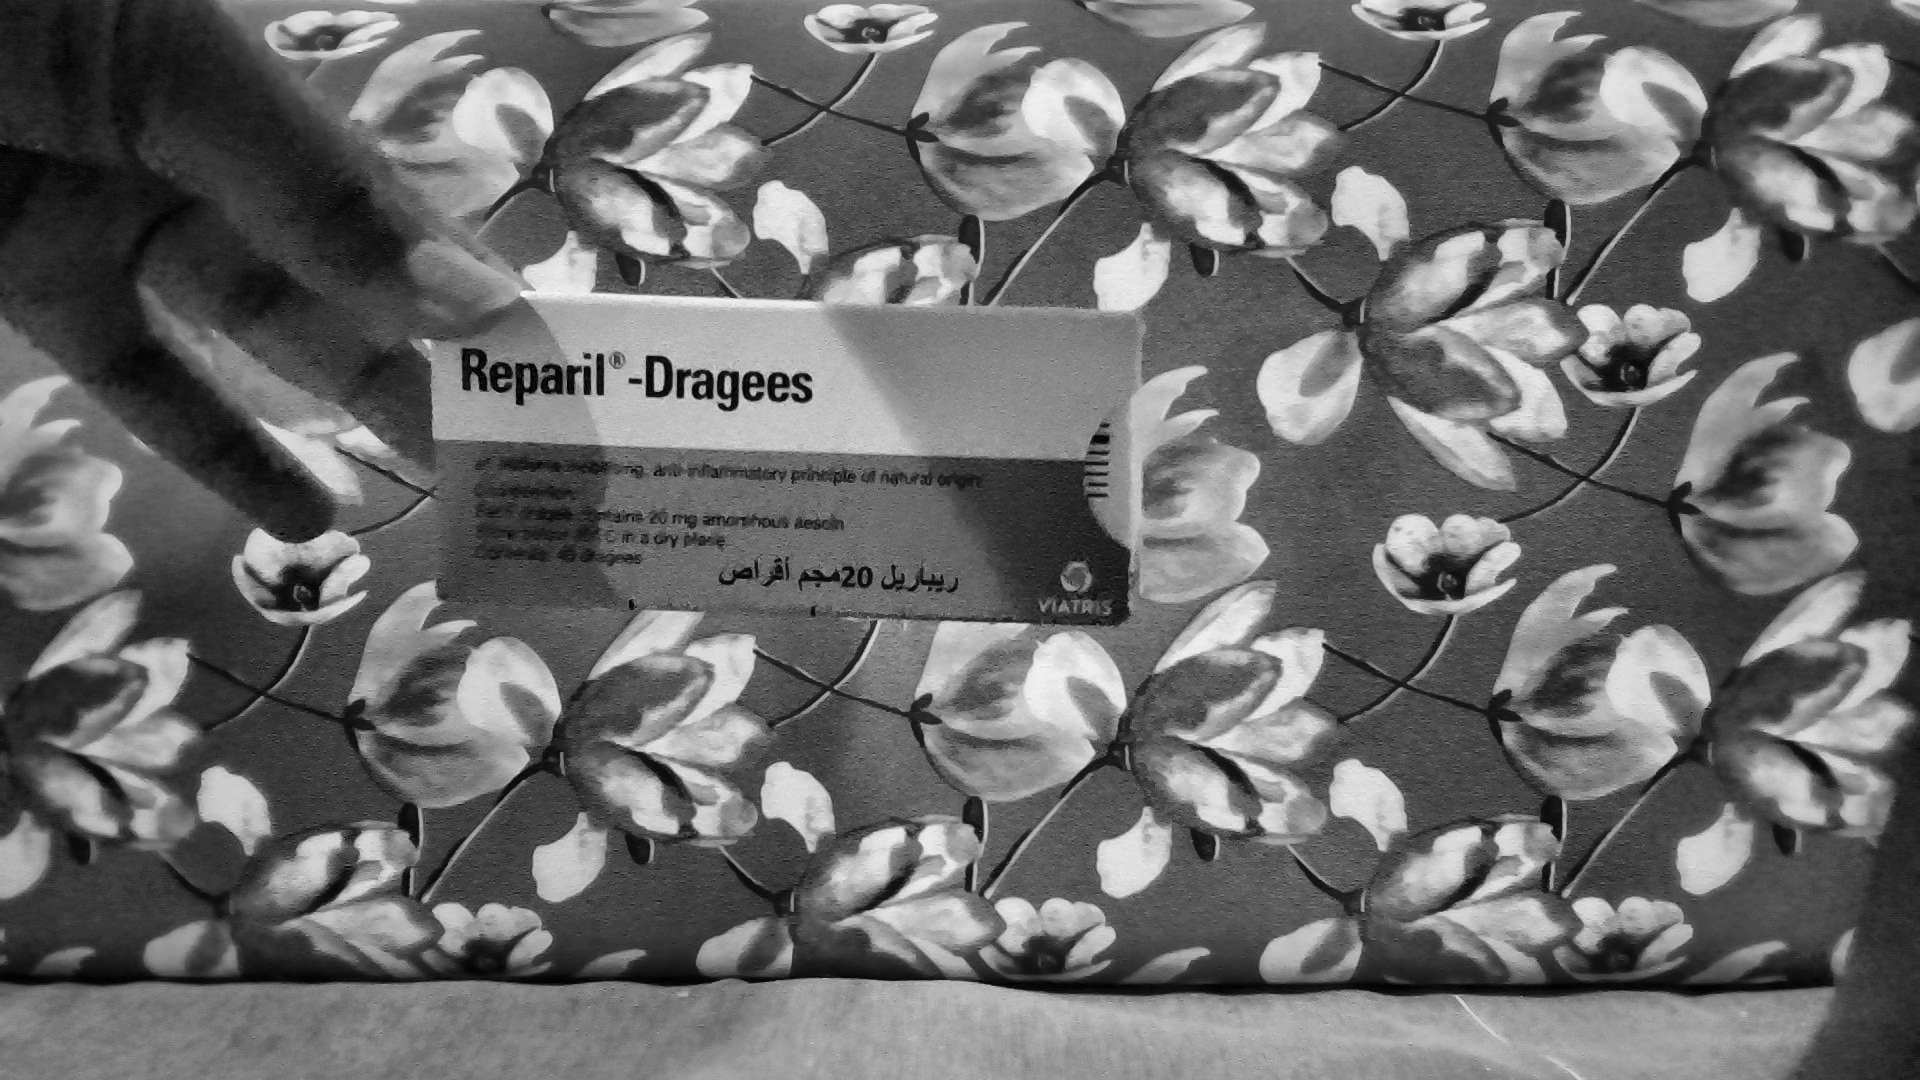

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



All text OCR detected: ['~', 'Reparil  Dragees', 'ريباريل 20 مجم أقر', 'اص', '٤ »٢ ٥٢ »٥', 'Hy ؛ant٣e  nm٧a', 'anor Aoia aescn', 'دتآرا', 'وان&', '٦٦٤']

✅ MATCHED via line 'Reparil  Dragees' (score: 62.5%)
Reparil 20mg Tab
Generic name: Aescin
Form: Coated Tablet, Strength: 20 mg, Pack size: 40 (Blister)
Route: Oral
Manufacturer: Rottapharm|Madaus Group
Legal status: Rx


In [ ]:
from google.colab.patches import cv2_imshow

photo_path = take_photo()
image = cv2.imread(photo_path)
processed = preprocess_image(image)

print("Preprocessed image:")
cv2_imshow(processed)

details = extract_medicine_details(processed)
print(f"\nAll text OCR detected: {details['all_detected']}")

match, match_score, matched_line = find_best_match(details["all_detected"], knowledge_base)

if match:
    print(f"\n✅ MATCHED via line {matched_line!r} (score: {match_score*100:.1f}%)")
    print(format_medicine_info(match))
else:
    print(f"\n❌ No confident match found (best score: {match_score*100:.1f}%, closest line was {matched_line!r})")